# OLS Regression - Model Building

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reading the dataset

In [ ]:
data = pd.read_csv('/content/Preprocessed_dataset_knn(5neighbour).csv')
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


# Dataset Inspection

In [ ]:
data.shape

(51867, 22)

In [ ]:
data.dtypes

,0
Project County,object
Project City,object
Gas Utility,object
Electric Utility,object
Total Project Cost,float64
Pre-Retrofit Home Heating Fuel Type,object
Year Home Built,int64
Size Of Home,int64
Number Of Units,int64
Job Type,object


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51867 entries, 0 to 51866
Data columns (total 22 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Project County                                        51867 non-null  object 
 1   Project City                                          51867 non-null  object 
 2   Gas Utility                                           51867 non-null  object 
 3   Electric Utility                                      51867 non-null  object 
 4   Total Project Cost                                    51867 non-null  float64
 5   Pre-Retrofit Home Heating Fuel Type                   51867 non-null  object 
 6   Year Home Built                                       51867 non-null  int64  
 7   Size Of Home                                          51867 non-null  int64  
 8   Number Of Units                                       51

In [ ]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


In [ ]:
data[data['First Year Modeled Project Energy Savings $ Estimate'].isna()]

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home


# Dropping null values as the number of null values is less than 1%

In [ ]:
data = data.dropna()

In [ ]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


# Building new feature columns and dropping the existing ones to solve for multicollinearity

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home'],
      dtype='object')

# Age of House

In [ ]:
data['Age of Home'] = data['Project Completion Year'] - data['Year Home Built']
data['Age of Home'].describe()

,Age of Home
count,51867.000000
mean,72.443326
std,29.468805
min,0.000000
25%,54.000000
50%,73.000000
75%,90.000000
max,233.000000


## Findings
Since the year built gives us when the house was built which is a static datapoint, we need to understand how old the building was when it was retrofitted. Energy efficiency depends on the age of the building rather than when it was built.

# Normalisation of data points

## Project Cost

In [ ]:
data['Total Project Cost'].describe()

,Total Project Cost
count,51867.000000
mean,6435.772476
std,4154.958606
min,129.000000
25%,3746.000000
50%,5929.000000
75%,8466.000000
max,92297.000000


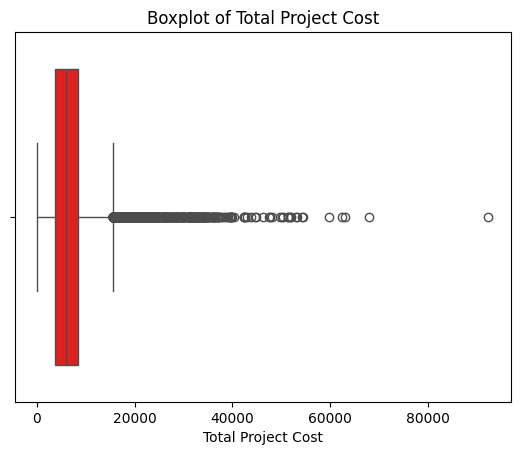

In [ ]:
sns.boxplot(x=data['Total Project Cost'], color='red')
plt.title('Boxplot of Total Project Cost')
plt.show()

### Finding

Using summary statistics and boxplot visualization, there is a significant gap between the 75th percentile and the maximum value, indicating the presence of extreme high value observations. The distribution is right skewed. We normalize by dividing by home size and then applying log transformation.

In [ ]:
data['Cost_per_Sqft'] = data['Total Project Cost'] / data['Size Of Home']
data['Cost_per_Sqft'].describe()

,Cost_per_Sqft
count,51867.000000
mean,4.485980
std,3.108841
min,0.089583
25%,2.302809
50%,3.963024
75%,6.038481
max,44.664000


In [ ]:
data['log_cost_per_Sqft'] = np.log(data['Cost_per_Sqft'] + 1)  # Adding 1 to avoid log(0)
data['log_cost_per_Sqft'].describe()

,log_cost_per_Sqft
count,51867.000000
mean,1.553283
std,0.558052
min,0.085795
25%,1.194773
50%,1.602015
75%,1.951392
max,3.821310


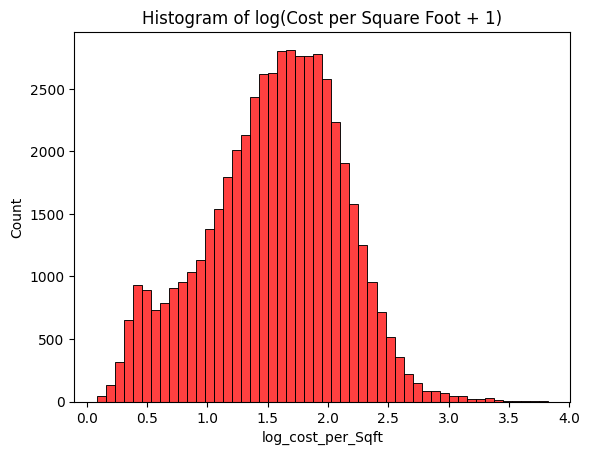

In [ ]:
sns.histplot(x=data['log_cost_per_Sqft'], color='red', bins=50)
plt.title('Histogram of log(Cost per Square Foot + 1)')
plt.show()

In [ ]:
data.rename(columns={'First Year Modeled Project Energy Savings $ Estimate': 'Log_Annual_Savings_Estimate_in_$'}, inplace=True)
data.drop(columns='Cost_per_Sqft', inplace=True)

## Estimated Annual kWh Savings

In [ ]:
data['Estimated Annual kWh Savings'].describe()

,Estimated Annual kWh Savings
count,51867.000000
mean,470.110186
std,1095.896135
min,-23368.000000
25%,158.000000
50%,443.000000
75%,536.000000
max,38572.000000


In [ ]:
data['kWh_savings_per_Sqft'] = data['Estimated Annual kWh Savings'] / data['Size Of Home']

## Estimated Annual MMBtu Savings per Sqft

In [ ]:
data['MMBtu_savings_per_Sqft'] = data['Estimated Annual MMBtu Savings'] / data['Size Of Home']

## Converting the MMBtu savings to kWh savings and merging with electric savings to get a new field called Total_energy_savings

In [ ]:
data['total_energy_savings_kwh'] = (
    data['Estimated Annual kWh Savings'] +
    data['Estimated Annual MMBtu Savings'] * 293.071
)

In [ ]:
data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh'] / data['Size Of Home']
data['total_energy_savings_kwh_sqft'].describe()

,total_energy_savings_kwh_sqft
count,51867.000000
mean,6.595226
std,5.332354
min,-2.225222
25%,3.032571
50%,5.621704
75%,9.024491
max,227.473268


In [ ]:
q1 = data['total_energy_savings_kwh_sqft'].quantile(0.01)
q99 = data['total_energy_savings_kwh_sqft'].quantile(0.99)

data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh_sqft'].clip(q1, q99)

### Tasks performed

A combined energy savings feature was constructed by converting MMBtu savings into kWh equivalents. This aggregated measure was further normalized by home size to derive energy savings per square foot, capturing efficiency across properties of varying sizes. Outlier treatment was applied using the 1st and 99th percentile clipping to reduce the impact of extreme values while preserving the overall distribution shape.

# Dropping redundant columns

In [ ]:
data.drop(columns=['Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'total_energy_savings_kwh'], inplace=True)

# Heatmap post feature extraction

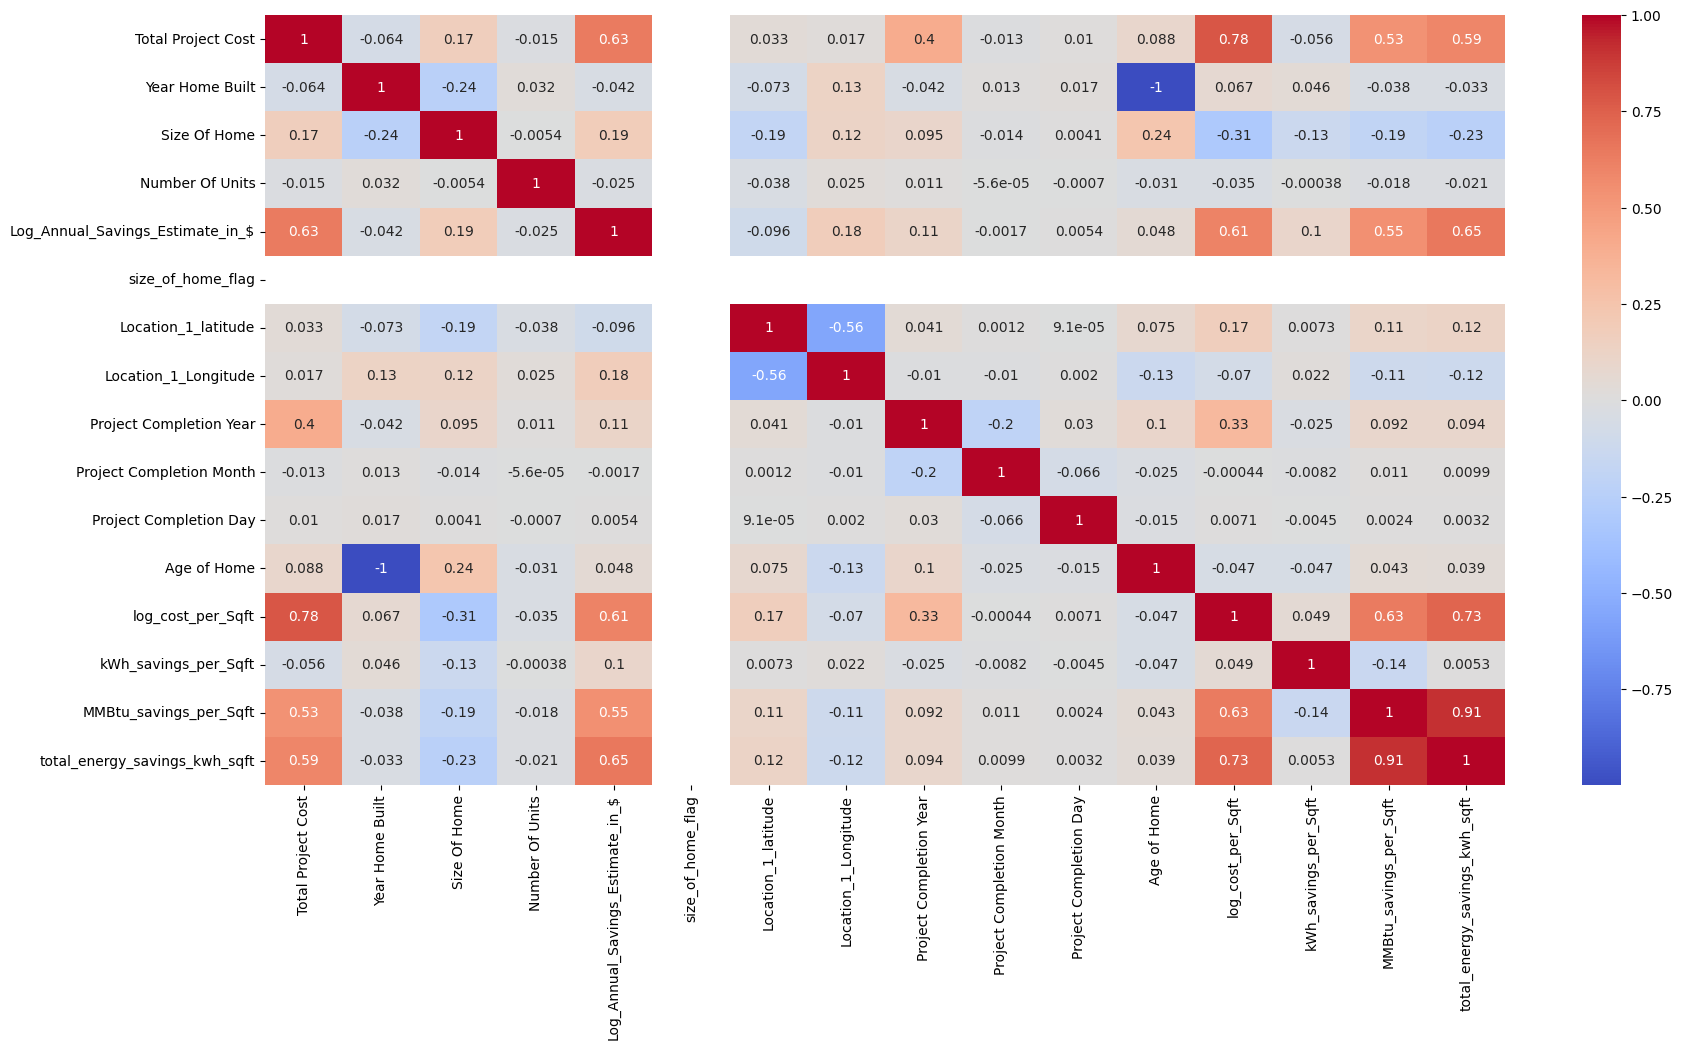

In [ ]:
numric_cols = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[numric_cols].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Dropping columns to handle multicollinearity

In [ ]:
data.drop(columns=['Year Home Built', 'MMBtu_savings_per_Sqft', 'kWh_savings_per_Sqft'], inplace=True)

In [ ]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

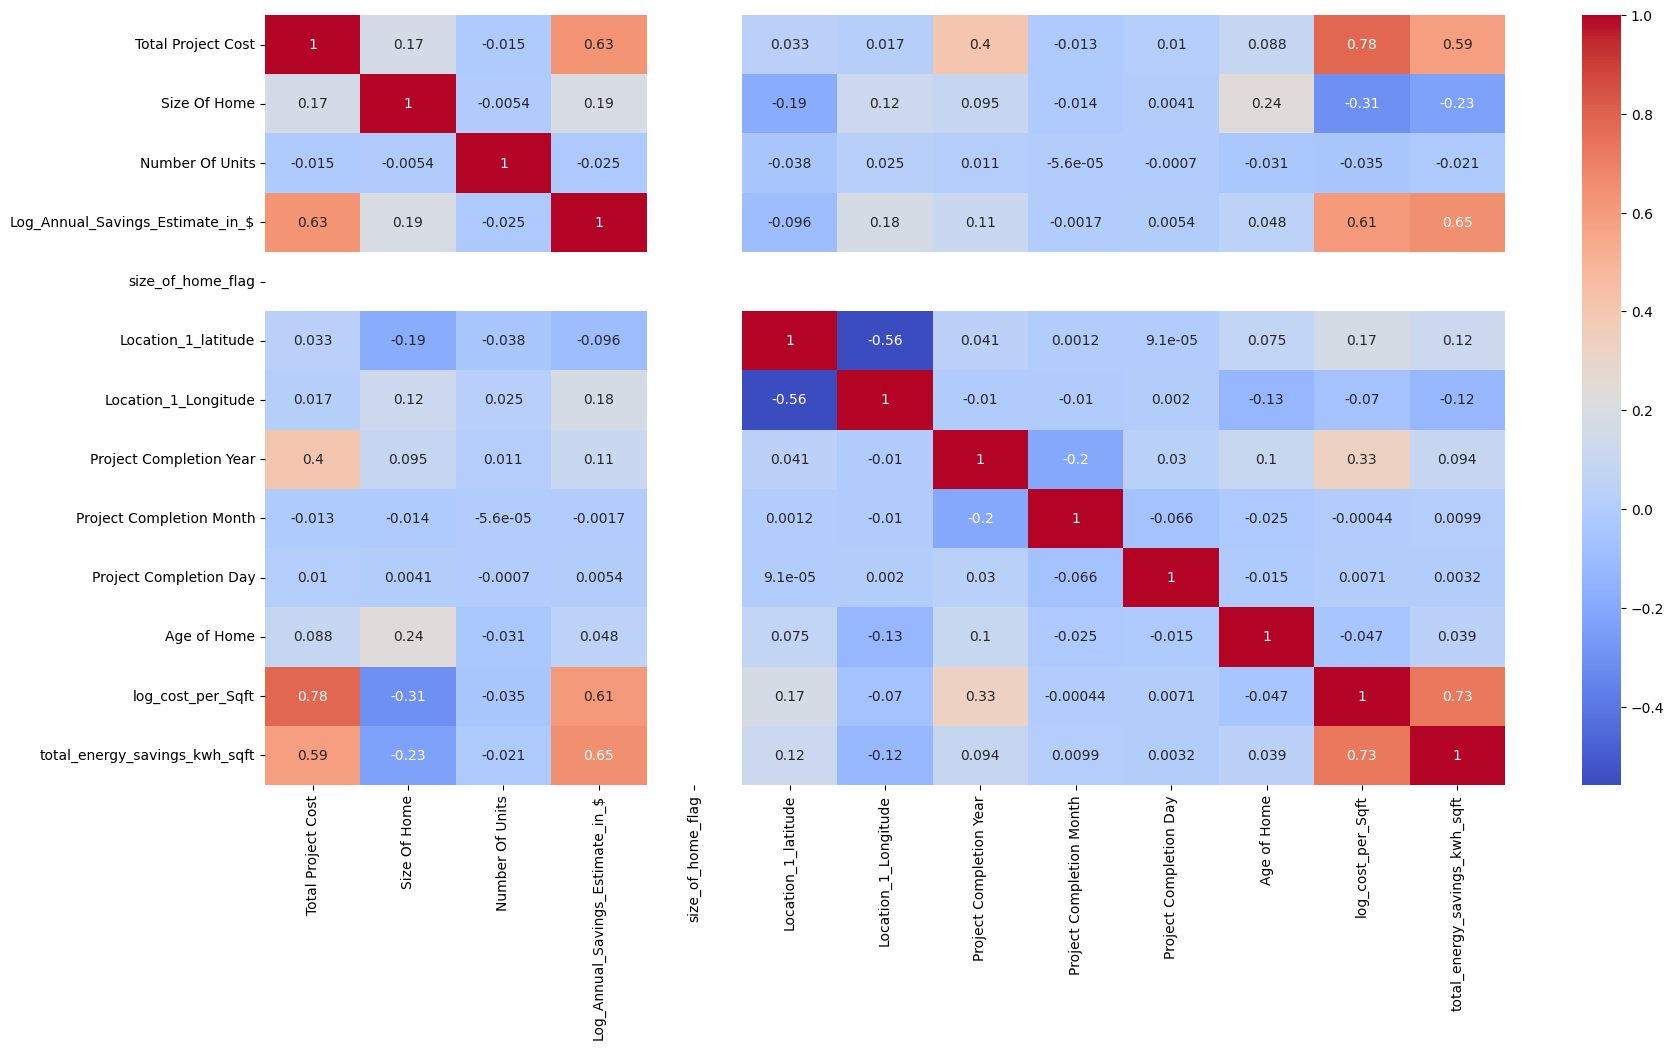

In [ ]:
num_col = data.select_dtypes(include=['int64', 'float64']).columns
corr = data[num_col].corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

# Target Variable

In [ ]:
data['Log_Annual_Savings_Estimate_in_$'].describe()

,Log_Annual_Savings_Estimate_in_$
count,51867.000000
mean,5.854329
std,0.875218
min,0.000000
25%,5.356586
50%,5.958425
75%,6.444131
max,10.199547


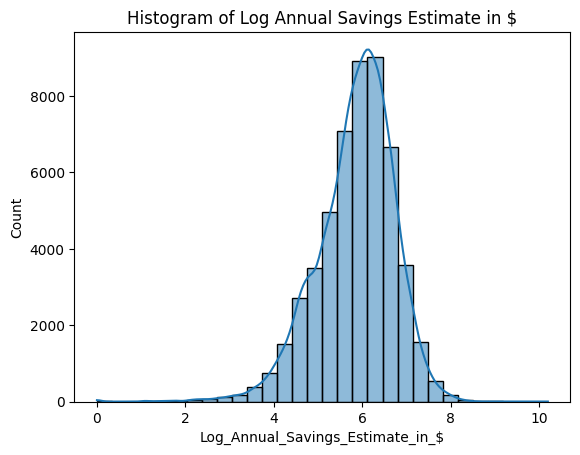

In [ ]:
sns.histplot(data['Log_Annual_Savings_Estimate_in_$'], bins=30, kde=True)
plt.title('Histogram of Log Annual Savings Estimate in $')
plt.show()

# Splitting the data into target variable (y) and independent variables (X)

In [ ]:
y = data['Log_Annual_Savings_Estimate_in_$']
X = data.drop(columns=['Log_Annual_Savings_Estimate_in_$'])

In [ ]:
X.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'size_of_home_flag', 'Location_1_latitude',
       'Location_1_Longitude', 'Project Completion Year',
       'Project Completion Month', 'Project Completion Day', 'Age of Home',
       'log_cost_per_Sqft', 'total_energy_savings_kwh_sqft'],
      dtype='object')

In [ ]:
X.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1484,1,Home Performance,Single Family,Building Shell,0,42.110115,-76.032545,2023,6,22,50,2.016250,4.926350
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1664,1,Home Performance,Single Family,Building Shell,0,40.697715,-73.786045,2023,6,22,90,2.095759,12.262431
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1252,1,Home Performance,Single Family,Building Shell,0,43.325035,-76.411740,2023,6,20,79,2.195626,14.092061
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1700,1,Home Performance,Single Family,Building Shell,0,44.695165,-74.704765,2023,6,13,109,1.618806,2.869450
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,2680,1,Home Performance,Single Family,Building Shell,0,43.231255,-75.868192,2023,6,13,132,1.720165,8.787141


# Encoding of categorical variables

In [ ]:
cat_col = X.select_dtypes(include=['object']).columns
cat_col

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Pre-Retrofit Home Heating Fuel Type', 'Job Type', 'Type Of Dwelling',
       'Measure Type'],
      dtype='object')

## Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_col:
    X[col] = le.fit_transform(X[col])
X.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,3,425,7,5,9661.0,4,1484,1,1,2,0,0,42.110115,-76.032545,2023,6,22,50,2.016250,4.926350
1,40,1103,5,1,11867.0,3,1664,1,1,2,0,0,40.697715,-73.786045,2023,6,22,90,2.095759,12.262431
2,37,488,5,4,9998.0,3,1252,1,1,2,0,0,43.325035,-76.411740,2023,6,20,79,2.195626,14.092061
3,49,937,10,4,6880.0,4,1700,1,1,2,0,0,44.695165,-74.704765,2023,6,13,109,1.618806,2.869450
4,37,260,5,4,12289.0,4,2680,1,1,2,0,0,43.231255,-75.868192,2023,6,13,132,1.720165,8.787141


# Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,-1.688746,-0.743469,0.583474,0.448009,0.776243,0.394222,-0.141343,-0.026711,0.200683,0.373341,-0.100847,0.0,-0.390346,0.045745,1.439575,-0.0129,0.715990,-0.761603,0.829620,-0.343753
1,0.845288,0.714950,-0.340983,-1.661844,1.307180,-0.364539,0.145439,-0.026711,0.200683,0.373341,-0.100847,0.0,-1.845611,1.270396,1.439575,-0.0129,0.715990,0.595777,0.972098,1.253140
2,0.639826,-0.607952,-0.340983,-0.079455,0.857352,-0.364539,-0.510972,-0.026711,0.200683,0.373341,-0.100847,0.0,0.861446,-0.160968,1.439575,-0.0129,0.484818,0.222498,1.151056,1.651407
3,1.461675,0.357874,1.970159,-0.079455,0.106916,0.394222,0.202795,-0.026711,0.200683,0.373341,-0.100847,0.0,2.273158,0.769567,1.439575,-0.0129,-0.324287,1.240533,0.117414,-0.791491
4,0.639826,-1.098394,-0.340983,-0.079455,1.408747,0.394222,1.764162,-0.026711,0.200683,0.373341,-0.100847,0.0,0.764819,0.135340,1.439575,-0.0129,-0.324287,2.021027,0.299045,0.496651


# Split the data into train and test split

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print(f'Training set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')

Training set size: (41493, 20)
Test set size: (10374, 20)


# OLS Regression (using statsmodels)

In [ ]:
# Add constant (intercept term) for OLS
x_train_const = sm.add_constant(x_train)
x_test_const = sm.add_constant(x_test)

In [ ]:
ols_model = sm.OLS(y_train, x_train_const).fit()
print(ols_model.summary())

                                   OLS Regression Results                                   
Dep. Variable:     Log_Annual_Savings_Estimate_in_$   R-squared:                       0.711
Model:                                          OLS   Adj. R-squared:                  0.711
Method:                               Least Squares   F-statistic:                     5376.
Date:                              Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                                      22:57:51   Log-Likelihood:                -27523.
No. Observations:                             41493   AIC:                         5.509e+04
Df Residuals:                                 41473   BIC:                         5.526e+04
Df Model:                                        19                                         
Covariance Type:                          nonrobust                                         
                                          coef    std err          t  

## OLS Coefficients

In [ ]:
coef_df = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'Std Error': ols_model.bse.values,
    'p-value': ols_model.pvalues.values,
    't-statistic': ols_model.tvalues.values
})

coef_df['Significant (p < 0.05)'] = coef_df['p-value'] < 0.05
coef_df = coef_df.sort_values('p-value')
coef_df

,Feature,Coefficient,Std Error,p-value,t-statistic,Significant (p < 0.05)
0,const,5.853314e+00,2.306578e-03,0.000000e+00,2537.661475,True
7,Size Of Home,4.084951e-01,3.764222e-03,0.000000e+00,108.520463,True
6,Pre-Retrofit Home Heating Fuel Type,1.418331e-01,2.420218e-03,0.000000e+00,58.603419,True
12,size_of_home_flag,-1.215173e-16,1.235778e-18,0.000000e+00,-98.332567,True
20,total_energy_savings_kwh_sqft,4.132402e-01,3.574207e-03,0.000000e+00,115.617296,True
19,log_cost_per_Sqft,4.710397e-01,6.627110e-03,0.000000e+00,71.077688,True
14,Location_1_Longitude,1.268219e-01,3.391920e-03,5.959508e-301,37.389417,True
15,Project Completion Year,-9.165605e-02,2.692666e-03,1.680633e-250,-34.039145,True
5,Total Project Cost,-1.097042e-01,5.511205e-03,9.353666e-88,-19.905657,True
4,Electric Utility,-9.021824e-02,5.082652e-03,3.125037e-70,-17.750230,True


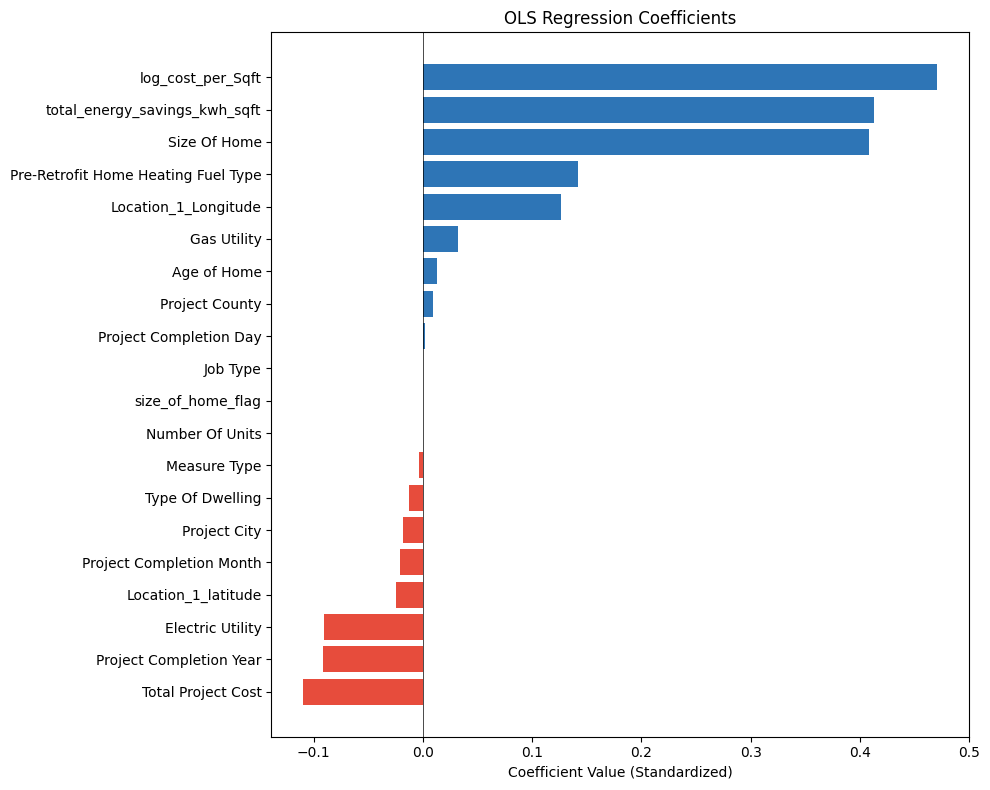

In [ ]:
# Coefficient bar plot (excluding constant)
plot_df = coef_df[coef_df['Feature'] != 'const'].sort_values('Coefficient')

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if c < 0 else '#2E75B6' for c in plot_df['Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (Standardized)')
plt.title('OLS Regression Coefficients')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## Predictions

In [ ]:
y_pred = ols_model.predict(x_test_const)
y_pred

,0
25886,4.420506
16112,6.717459
11667,6.562299
42784,5.001707
25850,6.814227
...,...
17532,3.791950
42235,5.403543
13312,5.799974
24633,6.071302


## Accuracy Measure

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.23233611016226374
Root Mean Squared Error: 0.48201256224528394
R-squared: 0.6997087285338882
Mean Absolute Error: 0.3226934856335191


In [ ]:
print(f'Adjusted R-squared: {ols_model.rsquared_adj}')
print(f'AIC: {ols_model.aic}')
print(f'BIC: {ols_model.bic}')
print(f'F-statistic: {ols_model.fvalue}')
print(f'F-statistic p-value: {ols_model.f_pvalue}')

Adjusted R-squared: 0.7110921599363914
AIC: 55086.041552812676
BIC: 55258.70715315853
F-statistic: 5375.985924046109
F-statistic p-value: 0.0


## Residual Analysis

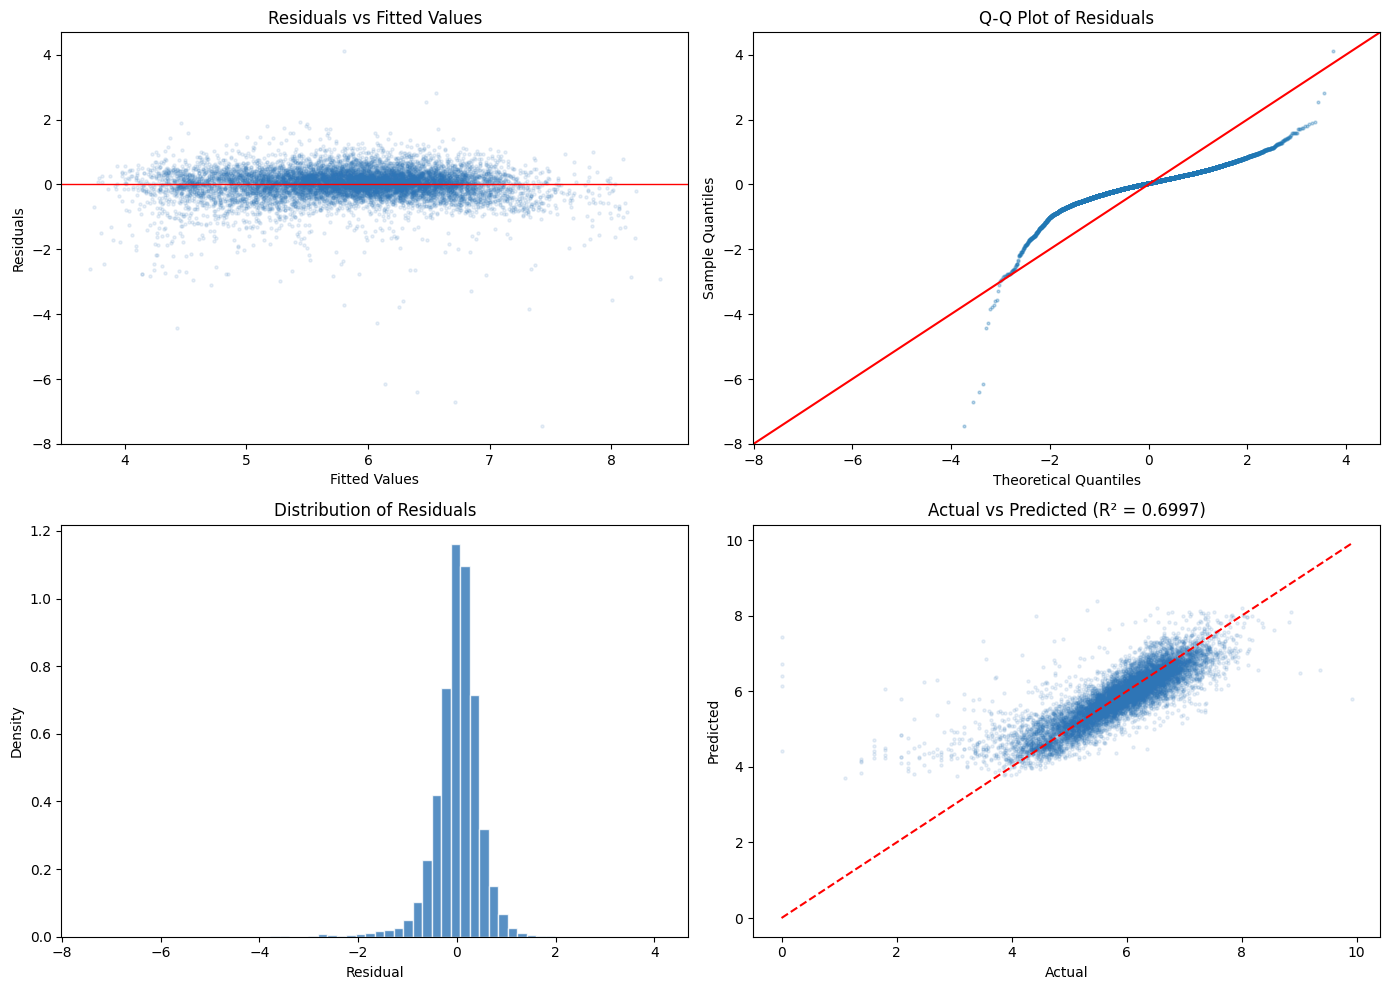

In [ ]:
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.1, s=5, color='#2E75B6')
axes[0, 0].axhline(y=0, color='red', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# 2. Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[0, 1], markersize=2, alpha=0.3)
axes[0, 1].set_title('Q-Q Plot of Residuals')

# 3. Histogram of residuals
axes[1, 0].hist(residuals, bins=60, color='#2E75B6', edgecolor='white', alpha=0.8, density=True)
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Distribution of Residuals')

# 4. Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred, alpha=0.1, s=5, color='#2E75B6')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title(f'Actual vs Predicted (R² = {r2:.4f})')

plt.tight_layout()
plt.show()

## Multicollinearity Check (VIF)

In [ ]:
vif_data = pd.DataFrame()
vif_data['Feature'] = x_train.columns
vif_data['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)
vif_data

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,Feature,VIF
18,log_cost_per_Sqft,8.289943
4,Total Project Cost,5.769243
3,Electric Utility,4.860361
2,Gas Utility,2.783642
6,Size Of Home,2.651507
19,total_energy_savings_kwh_sqft,2.401321
12,Location_1_latitude,2.223840
13,Location_1_Longitude,2.160759
8,Job Type,1.563797
9,Type Of Dwelling,1.559766


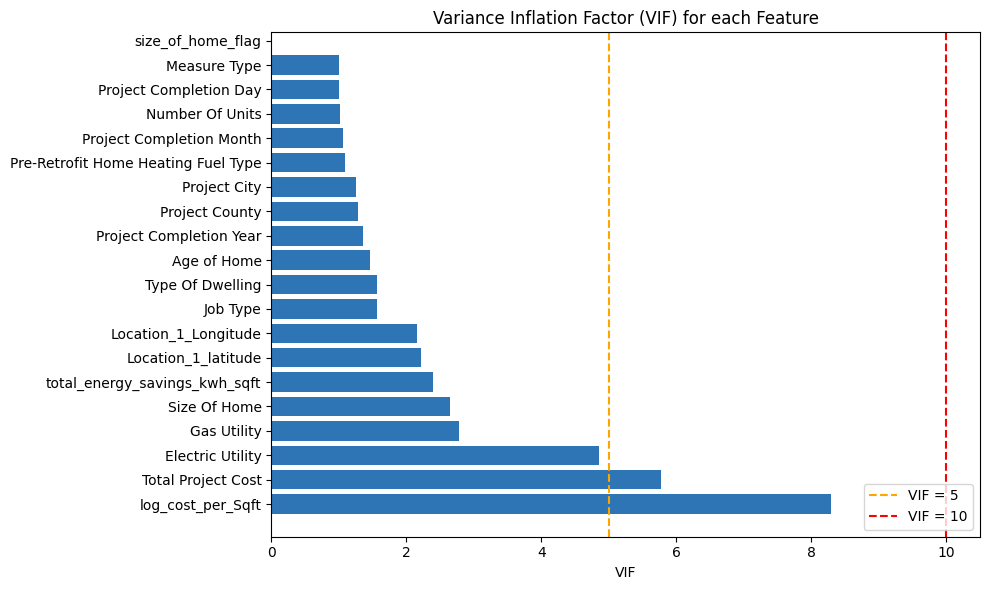

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(vif_data['Feature'], vif_data['VIF'], color='#2E75B6')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor (VIF) for each Feature')
plt.legend()
plt.tight_layout()
plt.show()

## Cross-Validation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lr = LinearRegression()
cv_r2 = cross_val_score(lr, X_scaled, y, cv=5, scoring='r2')
cv_rmse = -cross_val_score(lr, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')

print('5-Fold Cross-Validation Results')
print(f'R² scores: {cv_r2}')
print(f'Mean R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'RMSE scores: {cv_rmse}')
print(f'Mean RMSE: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}')

5-Fold Cross-Validation Results
R² scores: [0.65679145 0.66210231 0.69694244 0.73518353 0.74342774]
Mean R²: 0.6989 ± 0.0359
RMSE scores: [0.51694592 0.51900303 0.48189054 0.44203971 0.42160402]
Mean RMSE: 0.4763 ± 0.0392


# Summary

In [ ]:
print('OLS REGRESSION - SUMMARY OF RESULTS')
print(f'  R² (test):              {r2:.4f}')
print(f'  Adjusted R²:            {ols_model.rsquared_adj:.4f}')
print(f'  RMSE (test):            {rmse:.4f}')
print(f'  MAE (test):             {mae:.4f}')
print(f'  AIC:                    {ols_model.aic:.2f}')
print(f'  BIC:                    {ols_model.bic:.2f}')
print(f'  F-statistic:            {ols_model.fvalue:.2f}')
print(f'  5-Fold CV R²:           {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  Significant features:   {(ols_model.pvalues < 0.05).sum()} / {len(ols_model.pvalues)}')
high_vif = (vif_data['VIF'] > 10).sum()
print(f'  Features with VIF > 10: {high_vif}')

OLS REGRESSION - SUMMARY OF RESULTS
  R² (test):              0.6997
  Adjusted R²:            0.7111
  RMSE (test):            0.4820
  MAE (test):             0.3227
  AIC:                    55086.04
  BIC:                    55258.71
  F-statistic:            5375.99
  5-Fold CV R²:           0.6989 ± 0.0359
  Significant features:   17 / 21
  Features with VIF > 10: 0
